# Particle Swarn Optimization
Import Libraries


In [19]:
from __future__ import division
import random
import math
import numpy as np
from numpy import asarray
from numpy import arange
from matplotlib import pyplot as plt
from matplotlib import cm
from IPython import display
%matplotlib inline

#Define Objective Function and Derivative

In [25]:
#--- COST FUNCTION ------------------------------------------------------------+
# function we are attempting to optimize (minimize)
def objective(x):
    total=0
    for i in range(len(x)-1):
        total += 100 * (x[i+1] - x[i]**2)**2 + (1 - x[i])**2
    return total

Define auxiliary function for plotting

In [26]:
def plotCurrentSolution(bounds, bestSolution):
    ax = plt.axes(projection='3d')
    # sample input range uniformly at 0.1 increments
    X = arange(bounds[0,0], bounds[0,1], 0.1)
    Y = arange(bounds[1,0], bounds[1,1], 0.1)
    X, Y = np.meshgrid(X, Y)
    Z = 100 * (Y - (X**2))**2 + ( 1 - X )**2
    # Plot the surface.
    #surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax.contour3D(X, Y, Z, 50, cmap='binary')
    # plot the sample as black circles
    x, y , z = bestSolution[0], bestSolution[1], objective(bestSolution)
    ax.scatter(x, y, z, 'o', color='red')
    ax.view_init(60, 35)
    #plt.draw()#plt.show()
    display.display(plt.gcf())
    display.clear_output(wait=True)
    plt.pause(0.1)

### Define Particle Class

In [27]:
#--- MAIN ---------------------------------------------------------------------+
class Particle:
    def __init__(self,x0):
        self.position_i=[]          # particle position
        self.velocity_i=[]          # particle velocity
        self.pos_best_i=[]          # best position individual
        self.err_best_i=-1          # best error individual
        self.err_i=-1               # error individual

        for i in range(0,num_dimensions):
            self.velocity_i.append(random.uniform(-1,1))
            self.position_i.append(x0[i])

    # evaluate current fitness
    def evaluate(self, costFunc):
        self.err_i=costFunc(self.position_i)

        # check to see if the current position is an individual best
        if self.err_i < self.err_best_i or self.err_best_i==-1:
            self.pos_best_i = self.position_i
            self.err_best_i = self.err_i

    # update new particle velocity
    def update_velocity(self,pos_best_g):
        w = 0.5       # constant inertia weight (how much to weigh the previous velocity)
        c1 = 1        # cognitive constant
        c2 = 2        # social constant

        for i in range(0, num_dimensions):
            r1=random.random()
            r2=random.random()

            vel_cognitive=c1*r1*(self.pos_best_i[i]-self.position_i[i])
            vel_social=c2*r2*(pos_best_g[i]-self.position_i[i])
            self.velocity_i[i]=w*self.velocity_i[i]+vel_cognitive+vel_social

    # update the particle position based off new velocity updates
    def update_position(self,bounds):
        for i in range(0, num_dimensions):
            self.position_i[i]=self.position_i[i]+self.velocity_i[i]

            # adjust maximum position if necessary
            if self.position_i[i]>bounds[i, 1]:
                self.position_i[i]=bounds[i, 1]

            # adjust minimum position if necessary
            if self.position_i[i] < bounds[i, 0]:
                self.position_i[i]=bounds[i, 0]



## Define PSO Class

In [28]:
class PSO():
    def __init__(self, costFunc, x0, bounds, num_particles, maxiter):
        global num_dimensions

        num_dimensions=len(x0)
        err_best_g=-1                   # best error for group
        pos_best_g=[]                   # best position for group

        # establish the swarm
        swarm=[]
        for i in range(0,num_particles):
            swarm.append(Particle(x0))

        # begin optimization loop
        i=0
        while i < maxiter:
            #print i,err_best_g
            # cycle through particles in swarm and evaluate fitness
            for j in range(0, num_particles):
                swarm[j].evaluate(costFunc)

                # determine if current particle is the best (globally)
                if swarm[j].err_i < err_best_g or err_best_g == -1:
                    pos_best_g=list(swarm[j].position_i)
                    err_best_g=float(swarm[j].err_i)

            # cycle through swarm and update velocities and position
            for j in range(0,num_particles):
                swarm[j].update_velocity(pos_best_g)
                swarm[j].update_position(bounds)
            i+=1
            plotCurrentSolution(bounds, pos_best_g)

        # print final results
        print ('FINAL:')
        print (pos_best_g)
        print (err_best_g)

### Define Main Function

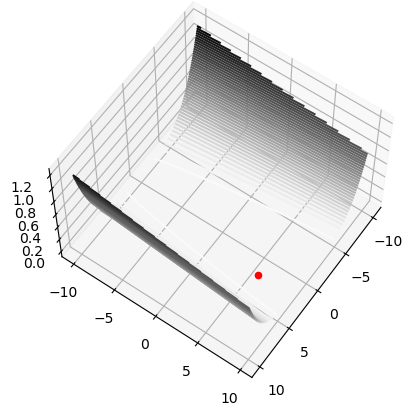

FINAL:
[2.4291494991609834, 5.895535781324598]
2.045205158494615


In [31]:
#--- RUN ----------------------------------------------------------------------+
initial=[7.5,7.5]               # initial starting location [x1,x2...]
bounds=asarray([[-10,10],[-10,10]])  # input bounds [[x1_min,x1_max],[x2_min,x2_max]...]
PSO(objective,initial,bounds,num_particles=15,maxiter=30)

#--- END ----------------------------------------------------------------------+